In [1]:
import numpy as np
import pandas as pd
import itertools
import pyro
import matplotlib.pyplot as plt
import seaborn as sns

## Flat treatment


In [2]:
p_prior = .5
p_drunk = .5
witness_if_guilty = .951 #sligth imbalance to go over .95 threshold
witness_if_innocent = .049
drunk_e_if_guilty = .4
drunk_e_if_innocent = .5
sober_e_if_guilty = .8
sober_e_if_innocent = .2


# posterior given the first item of evidence
p_w = witness_if_guilty * p_prior + witness_if_innocent * (1 - p_prior)
p_g_given_w = (witness_if_guilty * p_prior) / p_w

print(f"P(Guilty|Witness) = {p_g_given_w:.3f}")

# Integrate out drunk
p_e_if_guilty = p_drunk * drunk_e_if_guilty + (1 - p_drunk) * sober_e_if_guilty
p_e_if_innocent = p_drunk * drunk_e_if_innocent + (1 - p_drunk) * sober_e_if_innocent


print(f"P(Evidence|Guilty) = {p_e_if_guilty:.3f}")
print(f"P(Evidence|Innocent) = {p_e_if_innocent:.3f}")






P(Guilty|Witness) = 0.951
P(Evidence|Guilty) = 0.600
P(Evidence|Innocent) = 0.350


In [3]:
# Define regret table inside the function
regret = {
    1: {1: 0, 0: 19},  # convict
    0: {1: 1, 0: 0}    # not convict
}


# Function to compute regret for taking an action from a given perspective
def expected_regret_of_action(p_g_perspective, action):
    return p_g_perspective * regret[action][1] + (1 - p_g_perspective) * regret[action][0]

expected_regret_of_action(0.9, 0)

0.9

In [15]:
def expected_value_of_evidence_regret(current_p_g, p_e_if_guilty, p_e_if_innocent):
    """
    Compute the expected value of evidence (reduction in regret)
    given current posterior P(G|W) and probabilities of evidence given guilt.

    Args:
        current_p_g: Posterior probability of guilt given witness
        p_e_if_g1: P(E=1 | G=1)
        p_e_if_g0: P(E=1 | G=0)

    Returns:
        float: Expected value of evidence
    """


    # marginal of new evidence
    p_e1_given_w = p_e_if_guilty * current_p_g + p_e_if_innocent * (1 - current_p_g)
    p_e0_given_w = 1 - p_e1_given_w

    print(f"P(Evidence=1|Witness) = {p_e1_given_w:.3f}")
    print(f"P(Evidence=0|Witness) = {p_e0_given_w:.3f}")

    # posterior of guilt given witness and evidence
    p_g_given_w_e1 = (p_e_if_guilty * current_p_g) / p_e1_given_w
    p_g_given_w_e0 = ((1 - p_e_if_guilty) * current_p_g) / p_e0_given_w

    print(f"P(Guilty|Witness,Evidence=1) = {p_g_given_w_e1:.3f}")
    print(f"P(Guilty|Witness,Evidence=0) = {p_g_given_w_e0:.3f}")

    # optimal now
    optimal_w = 1 if expected_regret_of_action(current_p_g, 1) < expected_regret_of_action(current_p_g, 0) else 0
    print(f"Optimal action given current posterior: {'Convict' if optimal_w == 1 else 'Not Convict'}")

    # expected regret without evidence
    ER_no_evidence = expected_regret_of_action(current_p_g, optimal_w)
    print(f"Expected Regret without Evidence: {ER_no_evidence:.3f}")

    # Optimal actions given each possible evidence outcome
    optimal_e1 = 1 if expected_regret_of_action(p_g_given_w_e1, 1) < expected_regret_of_action(p_g_given_w_e1, 0) else 0
    optimal_e0 = 1 if expected_regret_of_action(p_g_given_w_e0, 1) < expected_regret_of_action(p_g_given_w_e0, 0) else 0

    print(f"Optimal action if Evidence=1: {'Convict' if optimal_e1 == 1 else 'Not Convict'}")
    print(f"Optimal action if Evidence=0: {'Convict' if optimal_e0 == 1 else 'Not Convict'}")

    #if E1, we perform action optimal_e1, convict 
    #if E0, we perform action optimal_e0, not convict

    # # now compute regrets from the perspective of current posterior
    R_e1 = expected_regret_of_action(p_g_given_w_e1, optimal_e1)
    R_e0 = expected_regret_of_action(p_g_given_w_e0, optimal_e0)

    print(f"Regret if Evidence=1: {R_e1:.3f}")
    print(f"Regret if Evidence=0: {R_e0:.3f}")

    ER_with_e = p_e1_given_w * R_e1 + p_e0_given_w * R_e0
    print(f"Expected Regret with Evidence: {ER_with_e:.3f}")

    # regrets as expected now
    NR_e1 = expected_regret_of_action(current_p_g, optimal_e1)
    NR_e0 = expected_regret_of_action(current_p_g, optimal_e0)

    NER = p_e1_given_w * NR_e1 + p_e0_given_w * NR_e0
    print(f"Expected Regret now (but taking optimal actions): {NER:.3f}")


expected_value_of_evidence_regret(p_g_given_w, p_e_if_guilty, p_e_if_innocent)

P(Evidence=1|Witness) = 0.588
P(Evidence=0|Witness) = 0.412
P(Guilty|Witness,Evidence=1) = 0.971
P(Guilty|Witness,Evidence=0) = 0.923
Optimal action given current posterior: Convict
Expected Regret without Evidence: 0.931
Optimal action if Evidence=1: Convict
Optimal action if Evidence=0: Not Convict
Regret if Evidence=1: 0.554
Regret if Evidence=0: 0.923
Expected Regret with Evidence: 0.706
Expected Regret now (but taking optimal actions): 0.939


## No early marginalization

In [18]:
def expected_value_of_evidence_regret_no_marg(
    current_p_g,
    p_drunk,
    drunk_e_if_guilty, drunk_e_if_innocent,
    sober_e_if_guilty, sober_e_if_innocent,
):
    
    # Two latent states
    latent_states = {
        "drunk": {
            "Pz": p_drunk,
            "p_e1_g1": drunk_e_if_guilty,
            "p_e1_g0": drunk_e_if_innocent
        },
        "sober": {
            "Pz": 1 - p_drunk,
            "p_e1_g1": sober_e_if_guilty,
            "p_e1_g0": sober_e_if_innocent
        },
    }

    ER_with_e = 0.0
    NER_with_e = 0.0

    for zname, zinfo in latent_states.items():
        Pz = zinfo["Pz"]
        p_e1_g1 = zinfo["p_e1_g1"]
        p_e1_g0 = zinfo["p_e1_g0"]

        print(f"--- Considering latent state: {zname} ---")
        print(f"P(Z={zname}) = {Pz:.3f}")

        # Predictive P(E=1 | W,z)
        p_e1_given_w_z = p_e1_g1 * current_p_g + p_e1_g0 * (1 - current_p_g)
        p_e0_given_w_z = 1 - p_e1_given_w_z

        print(f"P(Evidence=1|Witness,Z={zname}) = {p_e1_given_w_z:.3f}")
        print(f"P(Evidence=0|Witness,Z={zname}) = {p_e0_given_w_z:.3f}")

        # Posterior P(G|W,z,E=1)
        if p_e1_given_w_z > 0:
            p_g_w_z_e1 = (p_e1_g1 * current_p_g) / p_e1_given_w_z
        else:
            p_g_w_z_e1 = current_p_g  # degenerate

        print(f"P(Guilty|Witness,Evidence=1,Z={zname}) = {p_g_w_z_e1:.3f}")

        # Posterior P(G|W,z,E=0)
        p_g_w_z_e0 = ((1 - p_e1_g1) * current_p_g) / p_e0_given_w_z

        print(f"P(Guilty|Witness,Evidence=0,Z={zname}) = {p_g_w_z_e0:.3f}")

        # Optimal actions after observing E
        opt_e1 = 1 if expected_regret_of_action(p_g_w_z_e1,1) < \
                       expected_regret_of_action(p_g_w_z_e1,0) else 0
        opt_e0 = 1 if expected_regret_of_action(p_g_w_z_e0,1) < \
                       expected_regret_of_action(p_g_w_z_e0,0) else 0
        
        print(f"Optimal action if Evidence=1,Z={zname}: {'Convict' if opt_e1 == 1 else 'Not Convict'}")
        print(f"Optimal action if Evidence=0,Z={zname}: {'Convict' if opt_e0 == 1 else 'Not Convict'}")

        # Regret in each branch (use the branch posterior!)
        R_e1 = expected_regret_of_action(p_g_w_z_e1, opt_e1)
        R_e0 = expected_regret_of_action(p_g_w_z_e0, opt_e0)

        print(f"Regret in (z={zname}, E=1): {R_e1:.4f}")
        print(f"Regret in (z={zname}, E=0): {R_e0:.4f}")

        #Weight by P(z) * P(E=e | W,z)
        ER_with_e += Pz * (p_e1_given_w_z * R_e1 + p_e0_given_w_z * R_e0)

        # Regret from current perspective
        NR_e1 = expected_regret_of_action(current_p_g, opt_e1)
        NR_e0 = expected_regret_of_action(current_p_g, opt_e0)

        NER_with_e += Pz * (p_e1_given_w_z * NR_e1 + p_e0_given_w_z * NR_e0)


    print("\nTotal expected regret with E:", ER_with_e)
    print("Total expected regret now (but using e):", NER_with_e)

expected_value_of_evidence_regret_no_marg(
    p_g_given_w,
    p_drunk,
    drunk_e_if_guilty, drunk_e_if_innocent,
    sober_e_if_guilty, sober_e_if_innocent,)




--- Considering latent state: drunk ---
P(Z=drunk) = 0.500
P(Evidence=1|Witness,Z=drunk) = 0.405
P(Evidence=0|Witness,Z=drunk) = 0.595
P(Guilty|Witness,Evidence=1,Z=drunk) = 0.939
P(Guilty|Witness,Evidence=0,Z=drunk) = 0.959
Optimal action if Evidence=1,Z=drunk: Not Convict
Optimal action if Evidence=0,Z=drunk: Convict
Regret in (z=drunk, E=1): 0.9395
Regret in (z=drunk, E=0): 0.7822
--- Considering latent state: sober ---
P(Z=sober) = 0.500
P(Evidence=1|Witness,Z=sober) = 0.771
P(Evidence=0|Witness,Z=sober) = 0.229
P(Guilty|Witness,Evidence=1,Z=sober) = 0.987
P(Guilty|Witness,Evidence=0,Z=sober) = 0.829
Optimal action if Evidence=1,Z=sober: Convict
Optimal action if Evidence=0,Z=sober: Not Convict
Regret in (z=sober, E=1): 0.2416
Regret in (z=sober, E=0): 0.8291

Total expected regret with E: 0.61115
Total expected regret now (but using e): 0.9373430000000005


### Simulation

In [10]:
def drunk_evidence(p_prior = p_prior,
                    p_drunk = p_drunk,
                    witness_if_guilty = witness_if_guilty,
                    witness_if_innocent = witness_if_innocent,
                    drunk_e_if_guilty = drunk_e_if_guilty,
                    drunk_e_if_innocent = drunk_e_if_innocent,
                    sober_e_if_guilty = sober_e_if_guilty,
                    sober_e_if_innocent = .2):
    
    guilt = pyro.sample("guilt", pyro.distributions.Bernoulli(p_prior))

    p_witness = (witness_if_guilty * guilt +
                 witness_if_innocent * (1 - guilt))
    witness = pyro.sample("witness", pyro.distributions.Bernoulli(p_witness))

    is_drunk = pyro.sample("is_drunk", pyro.distributions.Bernoulli(p_drunk))

    # define arithmetically
    evidence_prob = (drunk_e_if_guilty * guilt * is_drunk +
                     drunk_e_if_innocent * (1 - guilt) * is_drunk +
                        sober_e_if_guilty * guilt * (1 - is_drunk) +
                        sober_e_if_innocent * (1 - guilt) * (1 - is_drunk))
    
    evidence = pyro.sample("evidence", pyro.distributions.Bernoulli(evidence_prob))

    return {"guilt": guilt, "witness": witness, "is_drunk": is_drunk,
             "evidence_prob": evidence_prob, "evidence": evidence}

result = drunk_evidence()
print(result)

{'guilt': tensor(1.), 'witness': tensor(1.), 'is_drunk': tensor(0.), 'evidence_prob': tensor(0.8000), 'evidence': tensor(1.)}


In [11]:
with pyro.plate("data_plate", 2e6):
    result = drunk_evidence()

result_dict = {k: v.numpy() for k, v in result.items()}
df = pd.DataFrame(result_dict)
display(df.head())

,guilt,witness,is_drunk,evidence_prob,evidence
0,0.0,0.0,0.0,0.2,0.0
1,1.0,1.0,0.0,0.8,1.0
2,0.0,0.0,1.0,0.5,0.0
3,0.0,0.0,1.0,0.5,0.0
4,0.0,0.0,0.0,0.2,0.0


In [12]:
# now c_regret
# zero if guilty
# 19 if innocent 
df['c_regret'] = np.where(df['guilt'] == 1, 0, 19)


# not c regret
df['not_c_regret'] = np.where(df['guilt'] == 1, 1, 0)

display(df.head())

,guilt,witness,is_drunk,evidence_prob,evidence,c_regret,not_c_regret
0,0.0,0.0,0.0,0.2,0.0,19,0
1,1.0,1.0,0.0,0.8,1.0,0,1
2,0.0,0.0,1.0,0.5,0.0,19,0
3,0.0,0.0,1.0,0.5,0.0,19,0
4,0.0,0.0,0.0,0.2,0.0,19,0


Probability of guilt if evidence and drunk: 0.9389685392379761
Probability of guilt if evidence and sober: 0.9871683120727539
Probability of guilt if no evidence and drunk: 0.9591987133026123
Probability of guilt if no evidence and sober: 0.8284411430358887


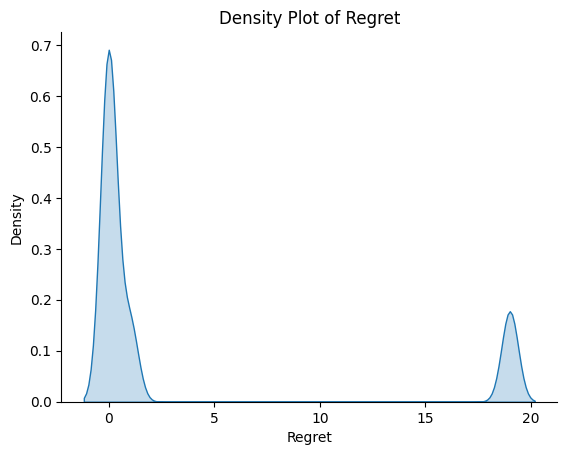

In [19]:
#subselect
df_drunk_evidence = df[(df['evidence'] == 1) & (df['is_drunk'] == 1) & (df['witness'] == 1)]
df_sober_evidence = df[(df['evidence'] == 1) & (df['is_drunk'] == 0) & (df['witness'] == 1)]
df_drunk_no_evidence = df[(df['evidence'] == 0) & (df['is_drunk'] == 1) & (df['witness'] == 1)]
df_sober_no_evidence = df[(df['evidence'] == 0) & (df['is_drunk'] == 0) & (df['witness'] == 1)]

guilt_if_evidence_drunk = df_drunk_evidence['guilt'].mean()
guilt_if_evidence_sober = df_sober_evidence['guilt'].mean()
guilt_if_no_evidence_drunk = df_drunk_no_evidence['guilt'].mean()
guilt_if_no_evidence_sober = df_sober_no_evidence['guilt'].mean()

print(f"Probability of guilt if evidence and drunk: {guilt_if_evidence_drunk}")
print(f"Probability of guilt if evidence and sober: {guilt_if_evidence_sober}")
print(f"Probability of guilt if no evidence and drunk: {guilt_if_no_evidence_drunk}")
print(f"Probability of guilt if no evidence and sober: {guilt_if_no_evidence_sober}")


# effectively
df['decision'] = np.where(
    ((df['evidence'] == 1) & (df['is_drunk'] == 0)) |
    ((df['evidence'] == 0) & (df['is_drunk'] == 1)),
    1, 0
)

df['regret'] = np.where(df['decision'] == 1, df['c_regret'], df['not_c_regret'])

sns.kdeplot(df['regret'], fill=True)
sns.despine()
plt.title("Density Plot of Regret")
plt.xlabel("Regret")
plt.ylabel("Density")
plt.show()


In [ ]:
# expected regrets 
expected_regret = df['regret'].mean()
print(f"Expected Regret: {expected_regret}")

Expected Regret: 3.4775665


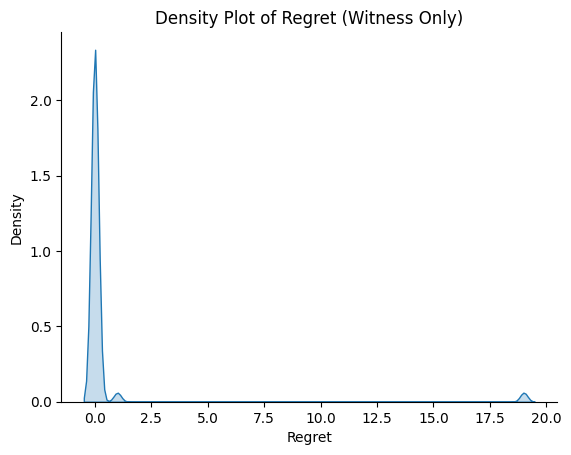

Expected Regret (Witness Only): 0.491631


In [20]:
# compare to evidence 
df['decision1'] = np.where(df['witness'] == 1, 1, 0)
df['regret1'] = np.where(df['decision1'] == 1, df['c_regret'], df['not_c_regret'])

sns.kdeplot(df['regret1'], fill=True)
sns.despine()
plt.title("Density Plot of Regret (Witness Only)")
plt.xlabel("Regret")
plt.ylabel("Density")
plt.show()

# expected regret
expected_regret1 = df['regret1'].mean()
print(f"Expected Regret (Witness Only): {expected_regret1}")

In [21]:
evidence_yes = df[df['evidence'] == 1]
evidence_no = df[df['evidence'] == 0]

c_expected_evidence_yes = evidence_yes['c_regret'].mean()
not_c_expected_evidence_yes = evidence_yes['not_c_regret'].mean()
print("If evidence is yes, expected c regret:", c_expected_evidence_yes)
print("If evidence is yes, expected not c regret:", not_c_expected_evidence_yes)


c_expected_evidence_no = evidence_no['c_regret'].mean()
not_c_expected_evidence_no = evidence_no['not_c_regret'].mean()
print("If evidence is no, expected c regret:", c_expected_evidence_no)
print("If evidence is no, expected not c regret:", not_c_expected_evidence_no)

pr_evidence_yes = len(evidence_yes) / len(df)
pr_evidence_no = len(evidence_no) / len(df)

overall_expected_regret = (pr_evidence_yes * min(c_expected_evidence_yes, not_c_expected_evidence_yes) +
                           pr_evidence_no * min(c_expected_evidence_no, not_c_expected_evidence_no))

print("Overall expected regret with evidence:", overall_expected_regret)


If evidence is yes, expected c regret: 7.013749148194171
If evidence is yes, expected not c regret: 0.6308553079897804
If evidence is no, expected c regret: 11.759543123950822
If evidence is no, expected not c regret: 0.38107667768679887
Overall expected regret with evidence: 0.49946999999999997
